# H-vector — p231 (filt2 uniform vs filt2 + 1/m_b)

Per-founder h estimates compared to per-founder pool truth, for each of the 6 p231 regimes × 2 weights. Same sorted-by-truth aesthetic as `H_FIX_METHODS_COMPARISON.ipynb`:
- x-axis: founder rank sorted by truth h ascending (truth = gray)
- estimated h overlaid as **blue (cactus)** / **orange (PG)** ×
- dashed red line: max present-founder truth (for visual reference)
- title: RMSE, spurious (h on truly-absent founders), cactus-mass `truth → est`

Truth h is read from `sims/<regime>/pool_weights.tsv` (per-founder pool fraction = visor clonefraction × multinomial count); estimated h is read from `*.h_per_chrom.npz` files emitted by `per_sample_per_chrom.py` (Chr1 vector). h is independent of the cn_var arm (cn_full is the EM input), so I read the atomized-arm h files.

In [1]:
import numpy as np, pandas as pd, json, math
import matplotlib.pyplot as plt
from pathlib import Path
ROOT=Path("/global/scratch/users/tbellg/hapfire_sv")
CTRL=ROOT/"control_p231"; SIMS=CTRL/"sims"; RES=CTRL/"results"
PLOTS=RES/"plots"; PLOTS.mkdir(parents=True,exist_ok=True)
CAC=set(map(str,json.load(open(ROOT/"data/founder_split_cactus_pg.json"))["cactus"]))
REGIMES=["n231_g0","n50_g0","n231_g1","n50_g1","n50_g3","n50_g3_dom500"]
WEIGHTS=["uniform","inv_mb"]; WLABEL={"uniform":"filt2 (uniform)","inv_mb":"filt2 + 1/m_b"}
def subdir(reg):
    if reg=="n50_g3_dom500": return "cov10_n50_g3_s42_hotspots_dom500_p231_chr1"
    n,g=reg.split("_g"); return f"cov10_{n}_g{g}_s42_hotspots_p231_chr1"

def load_truth_h(reg):
    """per-founder pool truth h (sum=1) from pool_weights.tsv."""
    df=pd.read_csv(SIMS/subdir(reg)/"pool_weights.tsv",sep="\t")
    return dict(zip(df["founder"].astype(str), df["weight"].astype(float)))

def load_est_h(reg,weight):
    wtag="filt2mb" if weight=="inv_mb" else "filt2u"
    p=RES/f"kmate_global_{wtag}_atomized"/reg/f"p231_{wtag}_atomized_{reg}_cov10_s42.h_per_chrom.npz"
    d=np.load(p,allow_pickle=True)
    fo=np.asarray(d["founders"]).astype(str); h=np.asarray(d["Chr1"]).astype(float)
    return fo, h

print("helpers ready")

helpers ready


## 6 regimes × 2 weights — h sorted by truth

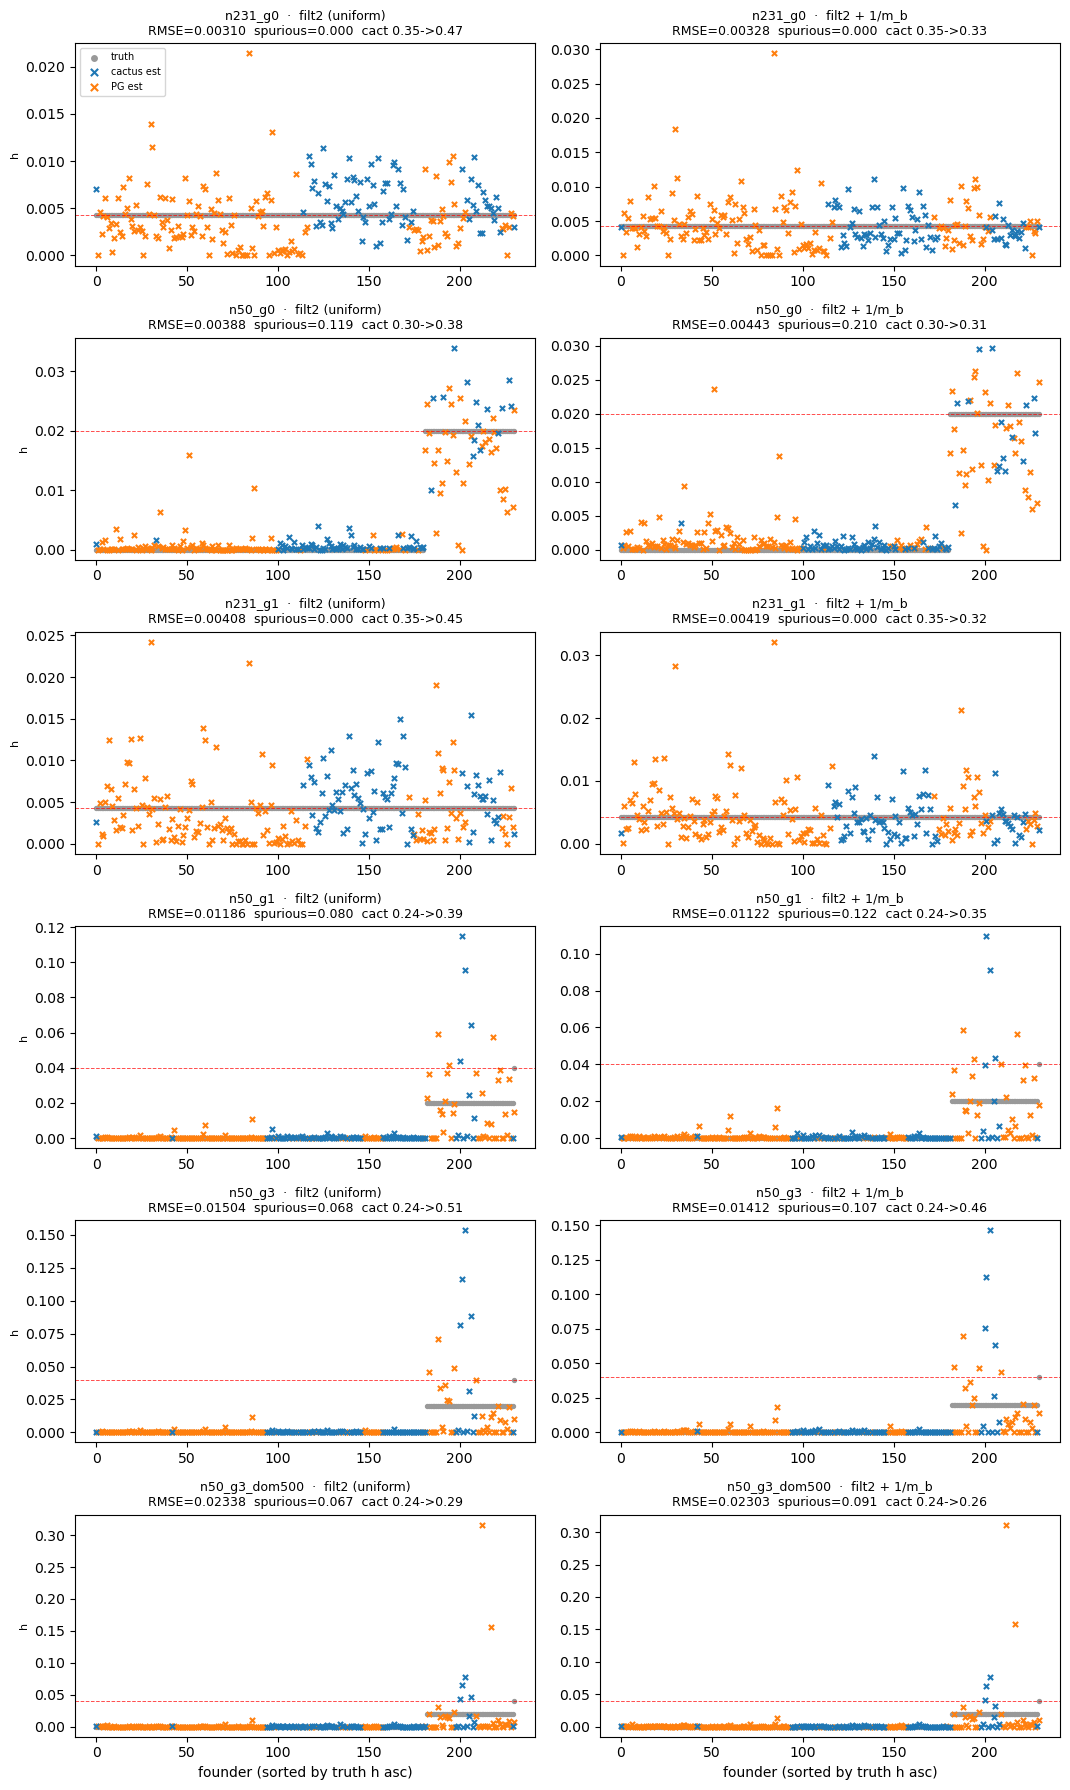

saved: /global/scratch/users/tbellg/hapfire_sv/control_p231/results/plots/H_VECTOR_p231_uniform_vs_inv_mb.png


In [2]:
fig, axes = plt.subplots(len(REGIMES), len(WEIGHTS), figsize=(5.4*len(WEIGHTS), 3.0*len(REGIMES)))
for i,reg in enumerate(REGIMES):
    th=load_truth_h(reg)
    for j,w in enumerate(WEIGHTS):
        ax=axes[i,j]
        fo,h_est=load_est_h(reg,w)
        t=np.array([th.get(f,0.0) for f in fo])
        cac=np.array([f in CAC for f in fo])
        order=np.argsort(t); t,h_est,cac,fo=t[order],h_est[order],cac[order],fo[order]
        x=np.arange(len(fo))
        ax.scatter(x, t, s=8, c="0.6", label="truth", zorder=1)
        ax.scatter(x[cac], h_est[cac], s=14, marker="x", c="#1f77b4", label="cactus est", zorder=3)
        ax.scatter(x[~cac], h_est[~cac], s=14, marker="x", c="#ff7f0e", label="PG est", zorder=2)
        # present-founder reference line
        lvl = t[t>0].max() if (t>0).any() else None
        if lvl: ax.axhline(lvl, ls="--", lw=0.7, c="red", alpha=0.7)
        rmse=math.sqrt(np.mean((h_est-t)**2))
        spur=float(h_est[t==0].sum())
        ct=float(t[cac].sum()); ce=float(h_est[cac].sum())
        ax.set_title(f"{reg}  ·  {WLABEL[w]}\nRMSE={rmse:.5f}  spurious={spur:.3f}  cact {ct:.2f}->{ce:.2f}", fontsize=9)
        if j==0: ax.set_ylabel("h", fontsize=8)
        if i==0 and j==0: ax.legend(fontsize=7, markerscale=1.4, loc="upper left")
for j in range(len(WEIGHTS)): axes[-1,j].set_xlabel("founder (sorted by truth h asc)")
fig.tight_layout()
out=PLOTS/"H_VECTOR_p231_uniform_vs_inv_mb.png"
fig.savefig(out, dpi=120, bbox_inches="tight"); plt.show()
print("saved:", out)

## Per-regime summary — h-vector metrics

In [3]:
rows=[]
for reg in REGIMES:
    th=load_truth_h(reg)
    for w in WEIGHTS:
        fo,h_est=load_est_h(reg,w)
        t=np.array([th.get(f,0.0) for f in fo])
        cac=np.array([f in CAC for f in fo])
        rmse=math.sqrt(np.mean((h_est-t)**2))
        mae=float(np.abs(h_est-t).mean())
        spur=float(h_est[t==0].sum())             # h mass on truly-absent founders
        ct=float(t[cac].sum()); ce=float(h_est[cac].sum())
        cact_bias=ce-ct
        rows.append(dict(regime=reg,weight=w,RMSE=rmse,MAE=mae,
                         spurious=spur,cactus_truth=ct,cactus_est=ce,cactus_bias=cact_bias))
summ=pd.DataFrame(rows)
pd.set_option("display.width",260,"display.max_columns",30,"display.max_rows",100)
print("\n=== full table ==="); print(summ.round(5).to_string(index=False))
print("\n=== uniform vs inv_mb RMSE per regime (lower=better) ===")
piv=summ.pivot(index="regime",columns="weight",values="RMSE")
piv["pct_change_inv_mb"]=(100*(piv["inv_mb"]-piv["uniform"])/piv["uniform"]).round(1)
print(piv.round(6))


=== full table ===
       regime  weight    RMSE     MAE  spurious  cactus_truth  cactus_est  cactus_bias
      n231_g0 uniform 0.00310 0.00239   0.00000       0.34632     0.46972      0.12340
      n231_g0  inv_mb 0.00328 0.00234   0.00000       0.34632     0.32653     -0.01979
       n50_g0 uniform 0.00388 0.00179   0.11925       0.30000     0.38438      0.08438
       n50_g0  inv_mb 0.00443 0.00233   0.20952       0.30000     0.31086      0.01086
      n231_g1 uniform 0.00408 0.00315   0.00000       0.34632     0.44653      0.10021
      n231_g1  inv_mb 0.00419 0.00285   0.00000       0.34632     0.31775     -0.02857
       n50_g1 uniform 0.01186 0.00456   0.07975       0.24000     0.39351      0.15351
       n50_g1  inv_mb 0.01122 0.00454   0.12165       0.24000     0.34854      0.10854
       n50_g3 uniform 0.01504 0.00522   0.06772       0.24000     0.51434      0.27434
       n50_g3  inv_mb 0.01412 0.00514   0.10704       0.24000     0.46327      0.22327
n50_g3_dom500 uniform 0